# Euler--Maruyama for the stochastic rotation game

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sun-mengwei/dtb-colab-experiments/blob/codex/game-dynamics-dtb/DTB_Game_Ver2/rotation_game_euler_maruyama_colab.ipynb)

The deterministic rotation example has game-gradient field

$$b(x)=\omega(x_2,-x_1),$$

coming from the two payoffs $\Pi_1=\omega x_1x_2$ and $\Pi_2=-\omega x_1x_2$. Here we add independent isotropic Brownian noise and simulate

$$dX_t=b(X_t)\,dt+\sigma\,dW_t.$$

Euler--Maruyama (EM) uses

$$X_{n+1}=X_n+h\,b(X_n)+\sigma\sqrt{h}\,Z_n,\qquad Z_n\sim N(0,I_2).$$

This notebook compares EM with the exact grid-time transition, checks the theoretical second moment, and shows why explicit EM slowly spirals outward for every fixed $h>0$. It is standalone and needs only NumPy and Matplotlib.

In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 120, "axes.grid": True})
print(f"NumPy {np.__version__}")

NumPy 2.1.3


## Configuration and model helpers

The initial cloud matches the off-center anisotropic Gaussian in `rotation_game_dtb_colab.ipynb`. The exact one-step transition is

$$X_{n+1}=R(\omega h)X_n+\sigma\sqrt{h}Z_n,$$

where $R$ is clockwise rotation. This transition is exact in law because rotating isotropic Brownian noise does not change its covariance. Reusing the normal draws for EM and the exact chain gives a low-variance comparison, but it should not be interpreted as both chains using the identical continuous Brownian path inside each step.

In [8]:
TEST_MODE = os.getenv("DTB_NOTEBOOK_TEST", "0") == "1"

omega = 1.0
sigma = 0.15
T = 2 * np.pi
h_nominal = 0.02
n_particles = 12_000
n_paths = 10
seed = 7

if TEST_MODE:
    T, h_nominal, n_particles, n_paths = 0.30, 0.05, 400, 4

n_steps = max(1, round(T / h_nominal))
h = T / n_steps  # adjust slightly so the final time is exactly T
times = np.arange(n_steps + 1) * h
rng = np.random.default_rng(seed)

initial_mean = np.array([0.6, 0.2])
initial_std = np.array([0.08, 0.25])
x0 = initial_mean + initial_std * rng.standard_normal((n_particles, 2))

def rotation_drift(x, omega=omega):
    return omega * np.stack((x[..., 1], -x[..., 0]), axis=-1)

def rotate_clockwise(x, angle):
    c, s = np.cos(angle), np.sin(angle)
    return np.stack((c * x[..., 0] + s * x[..., 1],
                     -s * x[..., 0] + c * x[..., 1]), axis=-1)

def euler_maruyama_step(x, z, h=h):
    return x + h * rotation_drift(x) + sigma * np.sqrt(h) * z

def exact_transition_step(x, z, h=h):
    return rotate_clockwise(x, omega * h) + sigma * np.sqrt(h) * z

print(f"T={T:.6f}, steps={n_steps}, h={h:.8f}, particles={n_particles:,}")

T=6.283185, steps=314, h=0.02001014, particles=12,000


## Simulate the ensemble

We propagate the same initial particles with EM and with the exact Markov transition. Five particle-cloud snapshots, a few EM sample paths, and the ensemble mean-squared radius are retained.

In [9]:
x_em = x0.copy()
x_exact = x0.copy()
mean_r2_em = np.empty(n_steps + 1)
mean_r2_exact = np.empty(n_steps + 1)
mean_r2_em[0] = np.mean(np.sum(x_em**2, axis=1))
mean_r2_exact[0] = np.mean(np.sum(x_exact**2, axis=1))

path_em = np.empty((n_steps + 1, n_paths, 2))
path_em[0] = x_em[:n_paths]
snapshot_steps = {round(n_steps * q / 4) for q in range(5)}
snapshots = {0: (x_em.copy(), x_exact.copy())}

for k in range(1, n_steps + 1):
    z = rng.standard_normal((n_particles, 2))
    x_em = euler_maruyama_step(x_em, z)
    x_exact = exact_transition_step(x_exact, z)
    mean_r2_em[k] = np.mean(np.sum(x_em**2, axis=1))
    mean_r2_exact[k] = np.mean(np.sum(x_exact**2, axis=1))
    path_em[k] = x_em[:n_paths]
    if k in snapshot_steps:
        snapshots[k] = (x_em.copy(), x_exact.copy())

print("simulation complete")

simulation complete


## Paths and particle clouds

The thin curves are individual EM sample paths. The black curve is the exact rotating mean $R(\omega t)\,E[X_0]$; additive zero-mean noise does not change it. In the cloud plots, exact particles are hollow so differences in spread remain visible.

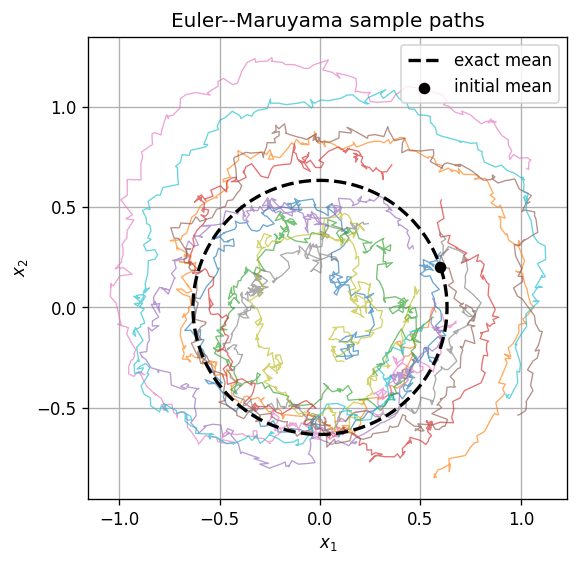

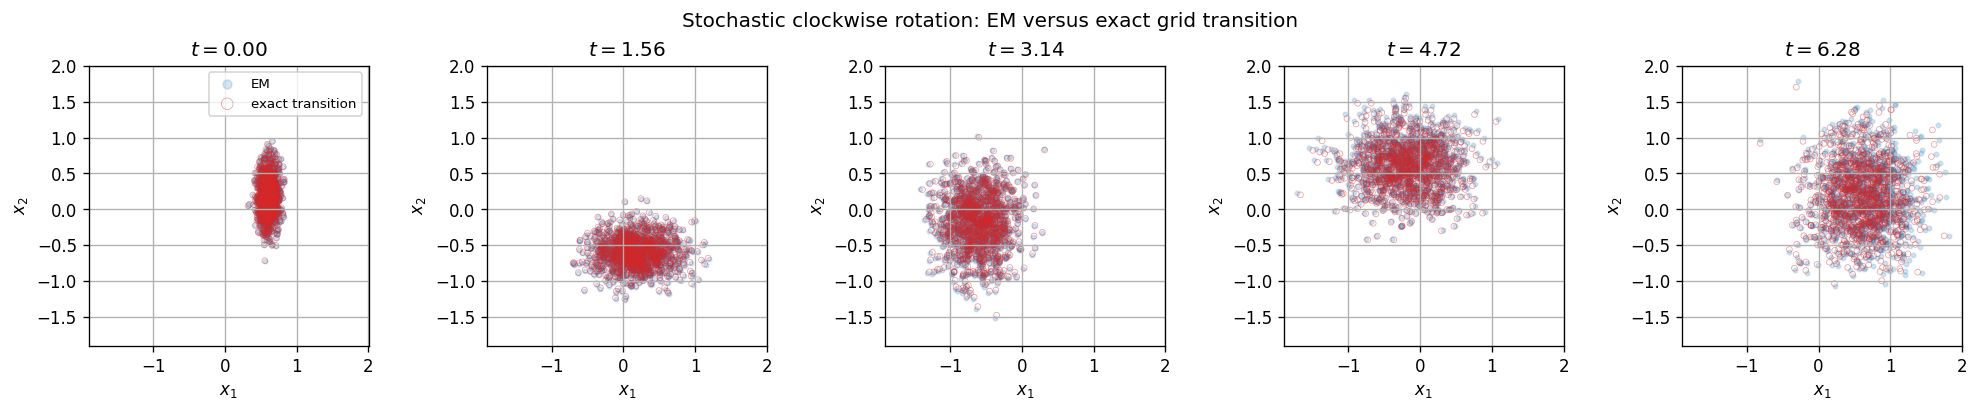

In [10]:
exact_mean_path = rotate_clockwise(np.broadcast_to(initial_mean, (len(times), 2)), omega * times)

fig, ax = plt.subplots(figsize=(5.4, 5.0))
for j in range(n_paths):
    ax.plot(path_em[:, j, 0], path_em[:, j, 1], lw=0.8, alpha=0.65)
ax.plot(exact_mean_path[:, 0], exact_mean_path[:, 1], "k--", lw=2, label="exact mean")
ax.scatter(*initial_mean, c="black", s=35, zorder=3, label="initial mean")
ax.set(xlabel="$x_1$", ylabel="$x_2$", title="Euler--Maruyama sample paths", aspect="equal")
ax.legend()
plt.show()

steps = sorted(snapshots)
plot_count = min(1_200, n_particles)
all_clouds = np.concatenate([cloud[:plot_count] for pair in snapshots.values() for cloud in pair])
lo, hi = all_clouds.min(), all_clouds.max()
pad = 0.05 * (hi - lo)
fig, axes = plt.subplots(1, len(steps), figsize=(3.35 * len(steps), 3.3), squeeze=False)
for ax, k in zip(axes[0], steps):
    em_cloud, exact_cloud = snapshots[k]
    ax.scatter(em_cloud[:plot_count, 0], em_cloud[:plot_count, 1], s=7, c="tab:blue",
               alpha=0.18, label="EM")
    ax.scatter(exact_cloud[:plot_count, 0], exact_cloud[:plot_count, 1], s=12,
               facecolors="none", edgecolors="tab:red", linewidths=0.45,
               alpha=0.45, label="exact transition")
    ax.set(title=fr"$t={k*h:.2f}$", xlabel="$x_1$", ylabel="$x_2$",
           xlim=(lo-pad, hi+pad), ylim=(lo-pad, hi+pad), aspect="equal")
axes[0, 0].legend(markerscale=2, fontsize=8)
fig.suptitle("Stochastic clockwise rotation: EM versus exact grid transition")
fig.tight_layout()
plt.show()

## Why EM spirals outward

Write $b(x)=Ax$, where

$$A=\begin{pmatrix}0&\omega\\-\omega&0\end{pmatrix}.$$

The deterministic part of one EM step is $I+hA$. Its eigenvalues are $1\pm i\omega h$, with modulus

$$|1\pm i\omega h|=\sqrt{1+\omega^2h^2}>1$$

for every $h>0$. Thus no positive fixed step is asymptotically stable for pure rotation. The exact second moment and the EM recurrence are

$$E\|X_t\|^2=E\|X_0\|^2+2\sigma^2t,$$

$$M_{n+1}=(1+\omega^2h^2)M_n+2\sigma^2h.$$

The noise causes the correct linear growth, while EM also multiplies the entire second moment by $1+\omega^2h^2$ at each step.

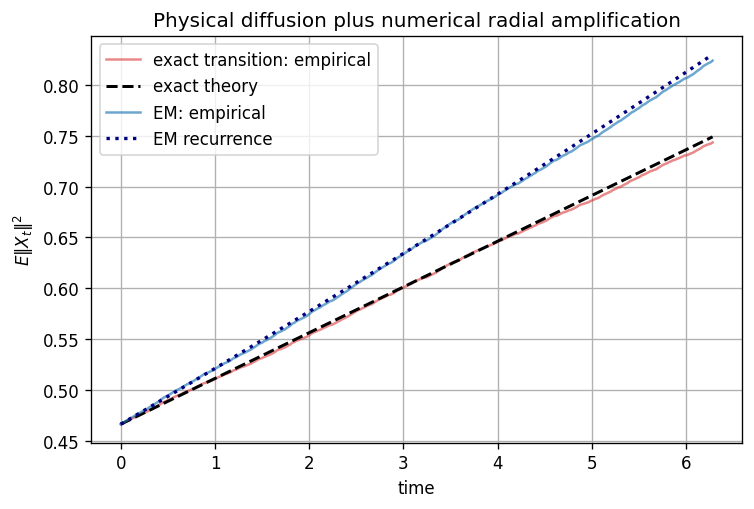

exact final second moment (theory): 0.748990
EM final second moment (theory):    0.829920
EM excess at T:                     0.080930
deterministic squared-radius amplification over [0,T]: 1.133945x


In [11]:
m0 = mean_r2_exact[0]
q = 1 + (omega * h)**2
exact_r2_theory = m0 + 2 * sigma**2 * times
if np.isclose(q, 1.0):
    em_r2_theory = exact_r2_theory.copy()
else:
    powers = q ** np.arange(n_steps + 1)
    em_r2_theory = powers * m0 + 2 * sigma**2 * h * (powers - 1) / (q - 1)

fig, ax = plt.subplots(figsize=(7.0, 4.4))
ax.plot(times, mean_r2_exact, color="tab:red", alpha=0.55, label="exact transition: empirical")
ax.plot(times, exact_r2_theory, "k--", lw=1.8, label="exact theory")
ax.plot(times, mean_r2_em, color="tab:blue", alpha=0.65, label="EM: empirical")
ax.plot(times, em_r2_theory, color="navy", ls=":", lw=2, label="EM recurrence")
ax.set(xlabel="time", ylabel=r"$E\|X_t\|^2$", title="Physical diffusion plus numerical radial amplification")
ax.legend()
plt.show()

print(f"exact final second moment (theory): {exact_r2_theory[-1]:.6f}")
print(f"EM final second moment (theory):    {em_r2_theory[-1]:.6f}")
print(f"EM excess at T:                     {em_r2_theory[-1] - exact_r2_theory[-1]:.6f}")
print(f"deterministic squared-radius amplification over [0,T]: {q**n_steps:.6f}x")

## Step-size refinement

EM is unstable over an arbitrarily long time horizon for any fixed $h>0$, but it is still convergent on a fixed finite interval as $h\to0$. The calculation below evaluates the closed-form EM second-moment bias at the same final time for several step sizes.

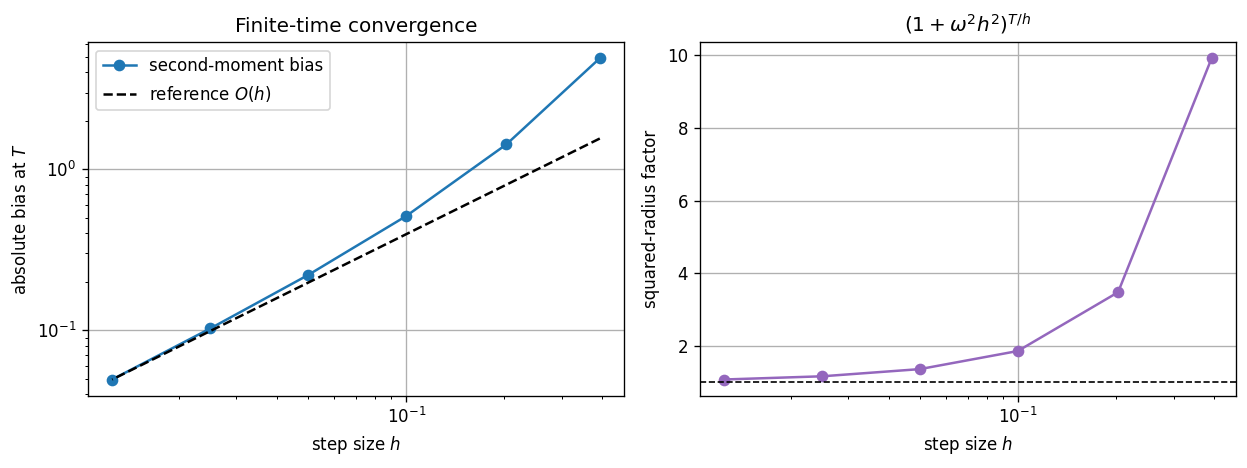

     h used | EM E||X_T||^2 | abs. bias | deterministic factor
   0.392699 |      5.64813250 |  4.90e+00 |          9.92139608
   0.202683 |      2.17555147 |  1.43e+00 |          3.48348897
   0.099733 |      1.26032821 |  5.11e-01 |          1.86553068
   0.049867 |      0.96912910 |  2.20e-01 |          1.36742835
   0.025033 |      0.85172305 |  1.03e-01 |          1.17027091
   0.012491 |      0.79842276 |  4.94e-02 |          1.08164150


In [12]:
def em_second_moment_at_T(h_requested):
    steps = max(1, round(T / h_requested))
    h_used = T / steps
    q_used = 1 + (omega * h_used)**2
    power = q_used**steps
    moment = power * m0 + 2 * sigma**2 * h_used * (power - 1) / (q_used - 1)
    return h_used, moment, power

requested_steps = (np.array([0.40, 0.20, 0.10, 0.05, 0.025, 0.0125])
                   if not TEST_MODE else T / np.array([2, 4, 8, 16, 32, 64]))
study = np.array([em_second_moment_at_T(value) for value in requested_steps])
h_values, moments, amplification = study.T
bias = np.abs(moments - exact_r2_theory[-1])
reference = bias[-1] * h_values / h_values[-1]

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.0))
axes[0].loglog(h_values, bias, "o-", label="second-moment bias")
axes[0].loglog(h_values, reference, "k--", label=r"reference $O(h)$")
axes[0].set(xlabel="step size $h$", ylabel="absolute bias at $T$", title="Finite-time convergence")
axes[0].legend()
axes[1].semilogx(h_values, amplification, "o-", color="tab:purple")
axes[1].axhline(1.0, color="black", ls="--", lw=1)
axes[1].set(xlabel="step size $h$", ylabel="squared-radius factor", title=r"$(1+\omega^2h^2)^{T/h}$")
fig.tight_layout()
plt.show()

print("     h used | EM E||X_T||^2 | abs. bias | deterministic factor")
for h_used, moment, error, factor in zip(h_values, moments, bias, amplification):
    print(f"{h_used:11.6f} | {moment:15.8f} | {error:9.2e} | {factor:19.8f}")

## Takeaway

For this rotation game, Euler--Maruyama does **not** have a positive long-time stability threshold: every fixed $h>0$ introduces outward amplification. Reducing $h$ controls the error on a fixed interval, but does not make the method asymptotically stable. If long-time preservation of the rotational geometry matters, use a structure-preserving drift step (for example, exact rotation or implicit midpoint) and then add the stochastic increment.